In [1]:
# IMPORTS AND SCENARIO DEFINITION
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import PercentFormatter
import matplotlib.gridspec as gridspec

from switch_model.tools.graph.main import GraphTools
from papers.Martin_Staadecker_et_al_2022.util import (
    get_scenario,
    set_style,
    save_df,
)

custom_color_map = LinearSegmentedColormap.from_list(
    "custom_color_map", ["#E0A4AA", "#B9646B", "#4D0409"]
)

# GET DATA FOR W/S RATIO
STORAGE_BINS = (float("-inf"), 10, 20, float("inf"))
STORAGE_LABELS = GraphTools.create_bin_labels(STORAGE_BINS)
for i in range(len(STORAGE_LABELS)):
    STORAGE_LABELS[i] = STORAGE_LABELS[i] + "h Storage (GW)"

# Define tools for wind to solar ratio set
baseline_ws_ratio = 0.187
# Get Graph tools
tools_ws_ratio = GraphTools\
        (
    scenarios=[
        get_scenario("WS10", 0.0909),
        get_scenario("WS018", 0.15),
        get_scenario("1342", baseline_ws_ratio),
        get_scenario("WS027", 0.21),
        get_scenario("WS033", 0.25),
        get_scenario("WS043", 0.3),
        get_scenario("WS066", 0.4),
        get_scenario("WS100", 0.5),
        get_scenario("WS150", 0.6),
        # get_scenario("WS233", 0.7), # Removed since results are invalid
        # get_scenario("WS500", 0.833), # Removed since results are misleading
    ],
    set_style=False,
)
tools_ws_ratio.pre_graphing(multi_scenario=True)

# Define tools for hydro set
tools_hydro = GraphTools(
    scenarios=[
        get_scenario("H25", 1),
        get_scenario("H025", 0.75),
        get_scenario("H050", 0.5),
        get_scenario("H065", 0.35),
        get_scenario("H085", 0.15),
        get_scenario("1342", 0),
    ],
    set_style=False,
)
tools_hydro.pre_graphing(multi_scenario=True)

#  GET TX DATA
tools_tx = GraphTools(
    scenarios=[
        get_scenario("T4", "No build costs\n(so no congestion)"),
        get_scenario("1342", "Baseline"),
        get_scenario("T5", "10x increase"),
    ],
    set_style=False,
)
tools_tx.pre_graphing(multi_scenario=True)

baseline_energy_cost = 22.43

# GET COST DATA
tools_cost = GraphTools(
    scenarios=[
        get_scenario("C21", 0.5),
        get_scenario("C18", 1),
        get_scenario("C22", 2),
        get_scenario("C23", 5),
        get_scenario("C26", 7),
        get_scenario("C17", 10),
        get_scenario("C24", 15),
        get_scenario("1342", baseline_energy_cost),
        get_scenario("C25", 40),
        get_scenario("C19", 70),
        get_scenario("C20", 102),
    ],
    set_style=False,
)
tools_cost.pre_graphing(multi_scenario=True)

def get_data(tools, normalize_to_baseline=None):
    storage = tools.get_dataframe("storage_capacity.csv")
    duration = storage.copy()
    duration = duration[duration["OnlinePowerCapacityMW"] != 0]
    duration["duration"] = (
        duration["OnlineEnergyCapacityMWh"] / duration["OnlinePowerCapacityMW"]
    )
    duration = duration[["scenario_index", "duration", "OnlinePowerCapacityMW"]]
    duration["Duration (h)"] = pd.cut(
        duration.duration, bins=STORAGE_BINS, labels=STORAGE_LABELS
    )
    duration = duration.groupby(
        ["scenario_index", "Duration (h)"]
    ).OnlinePowerCapacityMW.sum()
    duration /= 10 ** 3
    duration = duration.unstack()
    duration.index = duration.index.map(tools.get_scenario_name)

    storage = storage[["scenario_index", "OnlineEnergyCapacityMWh"]]
    storage = storage.groupby("scenario_index").sum()
    storage.index = storage.index.map(tools.get_scenario_name)
    storage *= 1e-6
    storage.columns = ["Storage Energy Capacity (TWh)"]

    # Calculate transmission
    tx = tools.get_dataframe(
        "transmission.csv",
        usecols=["BuildTx", "trans_length_km", "scenario_index"],
        convert_dot_to_na=True,
    ).fillna(0)
    tx["BuildTx"] *= tx["trans_length_km"]
    tx["BuildTx"] *= 1e-6
    tx = (
        tx.groupby("scenario_index", as_index=False)["BuildTx"]
        .sum()
        .set_index("scenario_index")
    )

    tx = tx.rename({"BuildTx": "New Tx"}, axis=1)
    tx.index = tx.index.map(tools.get_scenario_name)

    cap = tools.get_dataframe("gen_cap.csv")
    cap = tools.transform.gen_type(cap)
    cap = cap.groupby(["scenario_index", "gen_type"], as_index=False)[
        "GenCapacity"
    ].sum()
    cap = cap.pivot(columns="gen_type", index="scenario_index", values="GenCapacity")
    cap *= 1e-3  # Convert to GW
    cap = cap.rename_axis("Technology", axis=1).rename_axis(None)
    cap = cap[["Wind", "Solar"]]
    cap.index = cap.index.map(tools.get_scenario_name)

    # Make it a percent change compared to the baseline
    if normalize_to_baseline is not None:
        tx = tx / tx.loc[normalize_to_baseline]
        cap = cap / cap.loc[normalize_to_baseline]
        storage = storage / storage.loc[normalize_to_baseline]
        duration = duration / duration.sum(axis=1).loc[normalize_to_baseline]

    return duration, tx, cap, storage

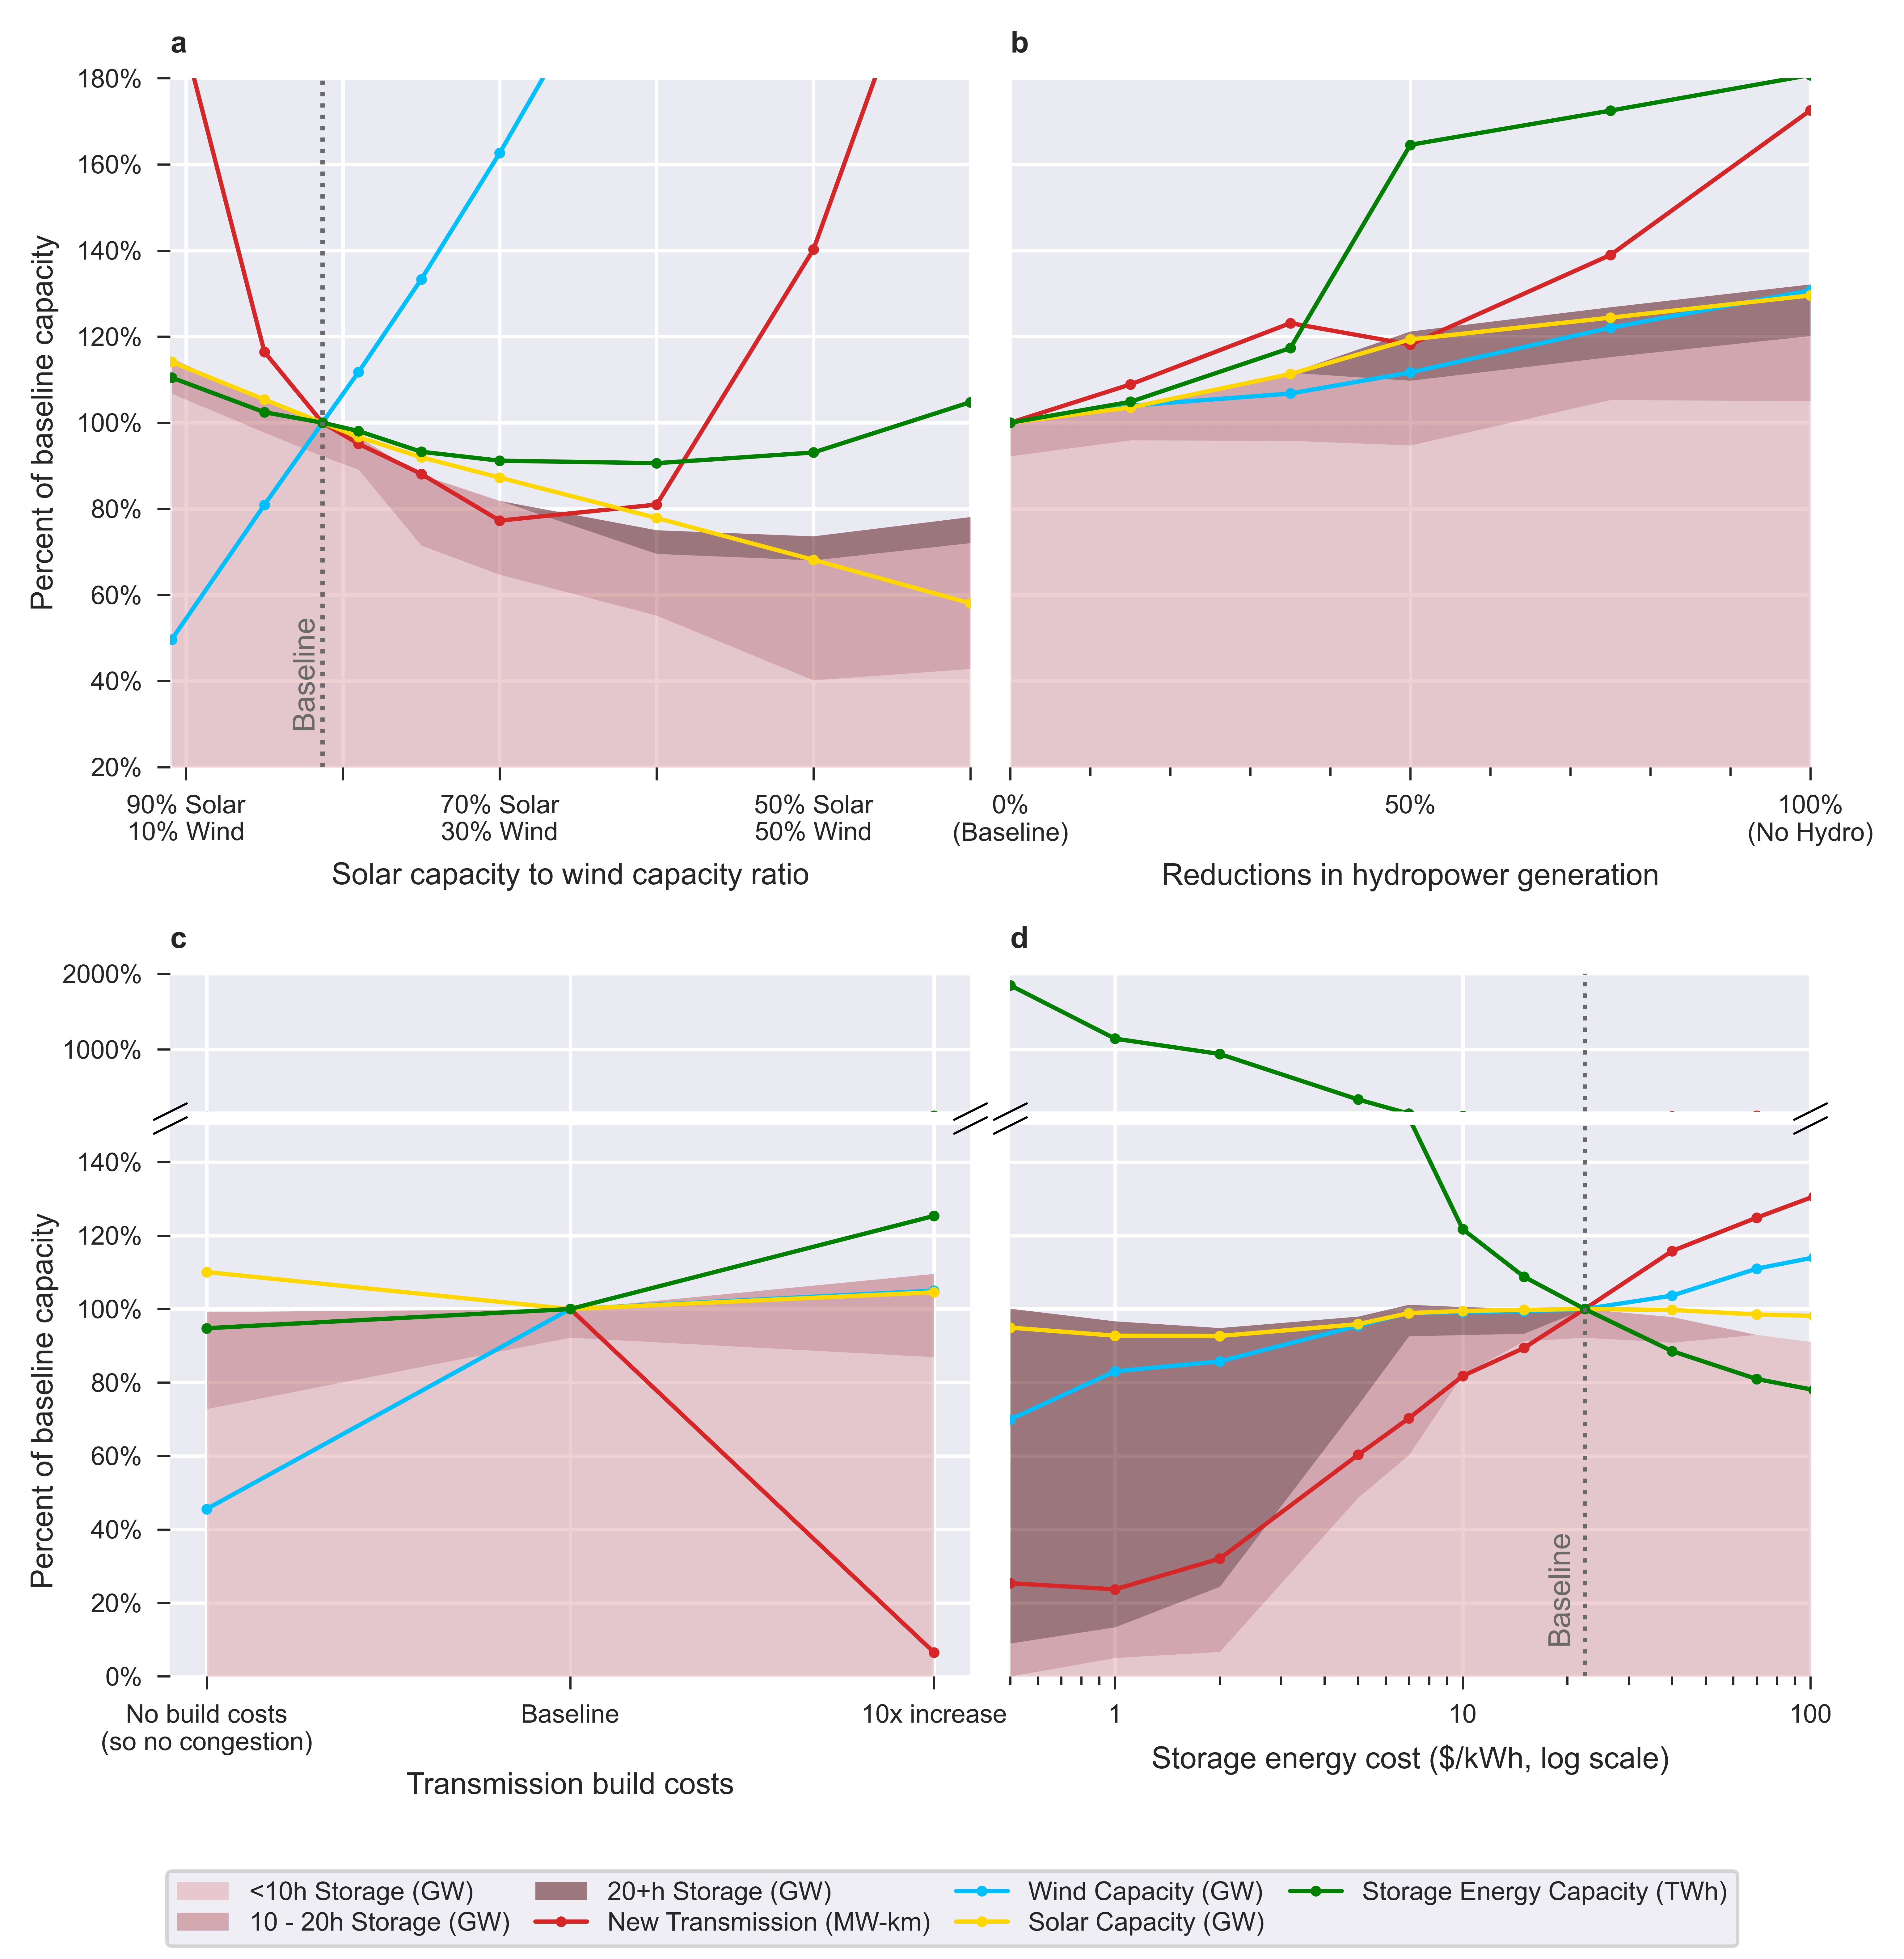

In [2]:
# %% DEFINE FIGURE AND PLOTTING FUNCTIONS
set_style()
plt.close()
fig = plt.figure()
fig.set_size_inches(6.850394, 6.850394)

gs = gridspec.GridSpec(5, 2, figure=fig, height_ratios=[50, 15, 10, 1, 40], hspace=0, wspace=0.05)

# Define axes

ax_tl = fig.add_subplot(gs[0, 0])
ax_tr = fig.add_subplot(gs[0, 1], sharey=ax_tl)
ax_bl = fig.add_subplot(gs[4, 0])
ax_bl_top = fig.add_subplot(gs[2, 0], sharex=ax_bl)
ax_br = fig.add_subplot(gs[4, 1], sharey=ax_bl)
ax_br_top = fig.add_subplot(gs[2, 1], sharex=ax_br, sharey=ax_bl_top)
ax_tl.set_ylim(0.2, 1.8)
ax_bl.set_ylim(0, 1.5)

ax_tl.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax_bl.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax_bl_top.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax_tl.set_ylabel("Percent of baseline capacity")
ax_bl.set_ylabel("Percent of baseline capacity")
ax_bl_top.set_ylim(1.8, 20)
ax_bl_top.tick_params(top=False, bottom=False, right=False, left=True, which="both")
ax_br_top.tick_params(top=False, bottom=False, right=False, left=False, which="both")
ax_bl_top.set_yticks([10, 20])
ax_br_top.set_xticklabels([])

d = .5  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=8,
              linestyle="none", color='k', mec='k', mew=0.5, clip_on=False)
ax_br_top.plot([0, 1], [0, 0], transform=ax_br_top.transAxes, **kwargs)
ax_br.plot([0, 1], [1, 1], transform=ax_br.transAxes, **kwargs)
ax_bl_top.plot([0, 1], [0, 0], transform=ax_bl_top.transAxes, **kwargs)
ax_bl.plot([0, 1], [1, 1], transform=ax_bl.transAxes, **kwargs)


# %% DEFINE PLOTTING CODE
def plot_panel(axes, rax, rrax, rrrax, data, title=""):
    if not isinstance(axes, tuple):
        axes = (axes, )
    duration, tx, cap, storage = data
    for table_name, table in {"duration": duration, "transmission": tx, "capacity": cap, "storage": storage}.items():
        save_df(table, f"figure-2-{title}-{table_name}.csv")
    lw = 1
    s = 3
    colors = tools_ws_ratio.get_colors()
    colors["Wind Capacity (GW)"] = colors["Wind"]
    colors["Solar Capacity (GW)"] = colors["Solar"]
    duration.index.name = None
    storage.index.name = None
    for i, ax in enumerate(axes):
        duration.plot(
            ax=ax,
            colormap=custom_color_map,
            legend=False,
            kind="area",
            zorder=1.5,
            alpha=0.5,
            linewidth=0,
        )
        ax.plot(
            tx,
            marker=".",
            color="tab:red",
            label="New Transmission (MW-km)",
            linewidth=lw,
            markersize=s
        )
        cap["Wind"].rename("Wind Capacity (GW)").plot(
            ax=ax, marker=".", color=colors, legend=False, linewidth=lw, markersize=s
        )
        cap["Solar"].rename("Solar Capacity (GW)").plot(
            ax=ax, marker=".", color=colors, legend=False, linewidth=lw, markersize=s
        )
        storage.plot(
            ax=ax, marker=".", color="green", linewidth=lw, markersize=s, legend=False
        )
    axes[0].set_title(title, loc="left", weight="bold")

# %% PLOT WIND TO SOLAR PENETRATION

data_ws = get_data(tools_ws_ratio, normalize_to_baseline=baseline_ws_ratio)

ax = ax_tl
# rax = rax_top_left
ax.tick_params(top=False, bottom=True, right=False, left=True, which="both")



plot_panel(ax, None, None, None, data_ws, "a")

ax.set_xlim([0.09, 0.6])
ax.set_xticks([0.1, 0.2, 0.3, 0.4, 0.5, 0.6])
ax.set_xticklabels(
    ["90% Solar\n10% Wind", "", "70% Solar\n30% Wind", "", "50% Solar\n50% Wind", ""]
)
ax.set_xlabel("Solar capacity to wind capacity ratio")
ax.axvline(baseline_ws_ratio, linestyle="dotted", color="dimgrey")
ax.text(baseline_ws_ratio - 0.02, 0.3, "Baseline", rotation=90, color="dimgrey")

fig.legend(loc="lower center", ncol=4)

# %% PLOT HYDRO
data_hy = get_data(tools_hydro, normalize_to_baseline=0)
ax = ax_tr
# rax = rax_top_right
plot_panel(ax, None, None, None, data_hy, "b")
ax.tick_params(top=False, bottom=True, right=False, left=False, which="both")
ax.set_xticks([0, 0.5, 1])
ax.set_xlim([0, 1])
ax.set_xticks([0.1, 0.2, 0.3, 0.4, 0.6, 0.7, 0.8, 0.9], minor=True)
ax.set_xticklabels(["0%\n(Baseline)", "50%", "100%\n(No Hydro)"])
ax.set_xlabel("Reductions in hydropower generation")
fig

# %% PLOT TX
ax = ax_bl
# rax = rax_bottom_left
data_tx = get_data(tools_tx, normalize_to_baseline="Baseline")
ax.set_xticks([0, 1, 2])
ax.tick_params(bottom=False, which="minor")
ax.tick_params(bottom=True, which="major")
data_tx[1].loc["No build costs\n(so no congestion)", "New Tx"] = None  # Remove point that is off the charts
plot_panel((ax_bl_top, ax), None, None, None, data_tx, "c")
ax.set_xlabel("Transmission build costs")
fig
# %% PLOT COSTS
ax = ax_br
# rax = rax_bottom_right
data_cost = get_data(tools_cost, normalize_to_baseline=baseline_energy_cost)
plot_panel((ax_br_top, ax), None, None, None, data_cost, "d")
ax.set_xscale("log")
ax.tick_params(top=False, bottom=True, right=False, left=False, which="both")
ax.set_xticks([1, 10, 100])
ax.set_xlim([0.5, 100])
ax.set_xticks(
    [
        0.5,
        0.6,
        0.7,
        0.8,
        0.9,
        1,
        2,
        3,
        4,
        5,
        6,
        7,
        8,
        9,
        10,
        20,
        30,
        40,
        50,
        60,
        70,
        80,
        90,
    ],
    minor=True,
)
ax.set_xticklabels(["1", "10", "100"])
ax.set_xlabel("Storage energy cost ($/kWh, log scale)")
ax.axvline(baseline_energy_cost, linestyle="dotted", color="dimgrey")
ax_br_top.axvline(baseline_energy_cost, linestyle="dotted", color="dimgrey")
ax.text(baseline_energy_cost - 5, 0.1, "Baseline", rotation=90, color="dimgrey")

# %% SAVE FIGURE
from papers.Martin_Staadecker_et_al_2022.util import save_figure
# plt.subplots_adjust(wspace=0.0, hspace=0.0)  # , left=0.08, right=0.97, top=0.95)
save_figure("figure-2-analysis-of-4-factors.svg")

In [115]:

# %% MAX POWER DURATION
df = tools_ws_ratio.get_dataframe("storage_capacity.csv")
df = df[df.scenario_name == 0.833]
df["duration"] = df["duration"] = (
    df["OnlineEnergyCapacityMWh"] / df["OnlinePowerCapacityMW"]
)
df = df[["load_zone", "duration", "OnlinePowerCapacityMW"]]
df.sort_values("duration")
# %% HYDRO POWER impact
en = data_hy[3].copy() * 1000
pw = data_hy[0].sum(axis=1).copy()
pw, en

# %% HYDRO power total capacity
df = tools_hydro.get_dataframe("dispatch_annual_summary.csv")
scenario = 1
# scenario = 0.5
df = df[df.scenario_name == scenario]
df = tools_hydro.transform.gen_type(df)
df = df[df.gen_type != "Storage"]
df = df.groupby("gen_type").Energy_GWh_typical_yr.sum()
df *= 1e-3
df
df.loc["Hydro"] / df.sum()
# %%
data_tx
# %% Storage duration in 50% hydro
df = tools_hydro.get_dataframe("dispatch_zonal_annual_summary.csv")
df = df[df.scenario_name == 1]
df = tools_hydro.transform.gen_type(df)
df = df[["gen_load_zone", "gen_type", "Energy_GWh_typical_yr"]].set_index(
    "gen_load_zone"
)
df_sum = df.groupby("gen_load_zone").Energy_GWh_typical_yr.sum()
df_sum = df_sum.rename("total")
df = df.join(df_sum)
cutoff = 0.5
df["percent"] = df["Energy_GWh_typical_yr"] / df["total"]
df = df[["percent", "gen_type"]].reset_index()
df = df[df.gen_type == "Hydro"]
df = df[df.percent > cutoff]
valid_load_zones = df["gen_load_zone"]

df = tools_hydro.get_dataframe("storage_capacity.csv")
# df = df[df.scenario_name == 0.5]
df = df[
    ["load_zone", "scenario_name", "OnlinePowerCapacityMW", "OnlineEnergyCapacityMWh"]
]
df = df[df.load_zone.isin(valid_load_zones)]
df = df.groupby("scenario_name").sum()
df["OnlineEnergyCapacityMWh"] / df["OnlinePowerCapacityMW"]
# valid_load_zones

# %% TX Change
df = data_tx[2]
df
# %% COSTS
df = data_cost
table = 1
df[table], (data_cost[table] / data_cost[table].loc[22.43] - 1) * 100
# %%
df = tools_cost.get_dataframe("storage_capacity.csv")
df["duration"] = df["OnlineEnergyCapacityMWh"] / df["OnlinePowerCapacityMW"]
df = df.groupby("scenario_name").duration.max()
df
# %%
df = tools_cost.get_dataframe("storage_capacity.csv")
df["duration"] = df["OnlineEnergyCapacityMWh"] / df["OnlinePowerCapacityMW"]
total_power = df.groupby("scenario_name").OnlinePowerCapacityMW.sum()
total_energy = df.groupby("scenario_name").OnlineEnergyCapacityMWh.sum()
total_energy / total_power
# %% California only costs
df = tools_cost.get_dataframe("storage_capacity.csv")
df = tools_cost.transform.load_zone(df)
df = df[df.region == "CA"]
df["duration"] = df["OnlineEnergyCapacityMWh"] / df["OnlinePowerCapacityMW"]
print("max duration", df.groupby("scenario_name").duration.max())
print("median duration", df.groupby("scenario_name").duration.median())
print("total capacity", df.groupby("scenario_name").OnlineEnergyCapacityMWh.sum() / 1e6)

cap = tools_cost.get_dataframe("gen_cap.csv")
cap = tools_cost.transform.gen_type(cap)
cap = cap.groupby(["scenario_index", "gen_type"], as_index=False)["GenCapacity"].sum()
cap = cap.pivot(columns="gen_type", index="scenario_index", values="GenCapacity")
cap *= 1e-3  # Convert to GW
cap = cap.rename_axis("Technology", axis=1).rename_axis(None)
cap = cap[["Solar"]]
cap.index = cap.index.map(tools_cost.get_scenario_name)
cap


max duration scenario_name
0.50      786.558733
1.00      619.814267
2.00      473.799651
5.00      211.585800
7.00       16.135559
10.00      10.819277
15.00       9.407417
22.43       8.203061
40.00       8.521841
70.00       8.754837
102.00      7.927618
Name: duration, dtype: float64
median duration scenario_name
0.50      162.708866
1.00      159.238585
2.00      134.206898
5.00       19.087454
7.00        8.511415
10.00       7.341131
15.00       7.073660
22.43       7.050063
40.00       7.153843
70.00       6.881627
102.00      6.336299
Name: duration, dtype: float64
total capacity scenario_name
0.50      15.654905
1.00      10.238870
2.00       9.706627
5.00       3.427390
7.00       0.950893
10.00      0.800768
15.00      0.766827
22.43      0.743310
40.00      0.724543
70.00      0.697605
102.00     0.695160
Name: OnlineEnergyCapacityMWh, dtype: float64


Technology,Solar
0.50,408.446095
1.00,399.000059
2.00,398.668445
5.00,412.487974
7.00,425.483107
10.00,427.980598
15.00,429.242346
22.43,430.246056
40.00,429.186361
70.00,423.820252
